In [22]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO

In [23]:
model = MobileNetV2(weights='imagenet')

model.input_shape

(None, 224, 224, 3)

In [24]:
model.output_shape

(None, 1000)

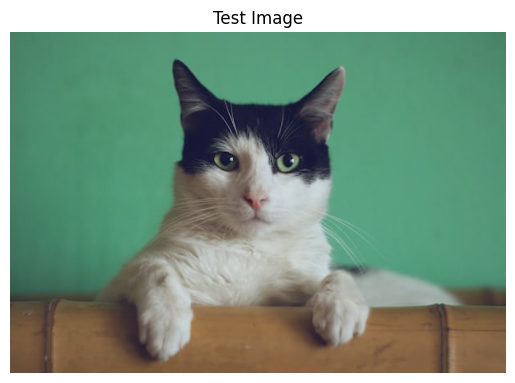

In [37]:
url = "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8Mnx8Y2F0fGVufDB8fDB8fHww"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}

response = requests.get(url, headers=headers)

if response.status_code == 200:
    img = Image.open(BytesIO(response.content))
    
    plt.imshow(img)
    plt.axis('off')
    plt.title('Test Image')
    plt.show()
else:
    print(f"Failed to download. Error code: {response.status_code}")

In [38]:
def preprocess_image(img):
    img = img.resize((224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array

processed = preprocess_image(img)
print("Processed shape:", processed.shape)


Processed shape: (1, 224, 224, 3)


In [39]:
predictions = model.predict(processed)
print("Predictions shape:", predictions.shape)

results = decode_predictions(predictions, top=5)[0]
print("\nTop 5 predictions:")
for rank, (id, label, confidence) in enumerate(results):
    print(f"{rank+1}. {label}: {confidence:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
Predictions shape: (1, 1000)

Top 5 predictions:
1. breastplate: 5.91%
2. carousel: 4.06%
3. pillow: 2.97%
4. lampshade: 2.64%
5. padlock: 2.34%
